### Load dataset configuration

This cell defines the dataset location and loads the YOLO dataset configuration file.  

In [ ]:
from pathlib import Path
import yaml

DATA_DIR = Path("../data")
DATA_YAML = DATA_DIR / "data.yaml"

print("Data folder exists:", DATA_DIR.exists())
print("data.yml exists:", DATA_YAML.exists())

with open(DATA_YAML, "r") as f:
    data_config = yaml.safe_load(f)

print(data_config)

Data folder exists: True
data.yml exists: True
{'train': 'train/images', 'val': 'valid/images', 'test': 'test/images', 'nc': 8, 'names': ['Ancylostoma Spp', 'Ascaris Lumbricoides', 'Enterobius Vermicularis', 'Fasciola Hepatica', 'Hymenolepis', 'Schistosoma', 'Taenia Sp', 'Trichuris Trichiura'], 'roboflow': {'workspace': 'roboflow-100', 'project': 'parasites-1s07h', 'version': 2, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/roboflow-100/parasites-1s07h/dataset/2'}}


### Verify dataset paths

This cell checks whether the train, validation, and test image folders defined in `data.yaml` exist.  

In [ ]:
train_images = DATA_DIR / data_config["train"]
val_images = DATA_DIR / data_config["val"]
test_images = DATA_DIR / data_config["test"]

print("Train images path:", train_images)
print("Exists:", train_images.exists())

print("Val images path:", val_images)
print("Exists:", val_images.exists())

print("Test images path:", test_images)
print("Exists:", test_images.exists())

Train images path: ../data/train/images
Exists: True
Val images path: ../data/valid/images
Exists: True
Test images path: ../data/test/images
Exists: True


### Count images per split

This cell counts the number of image files in each dataset split.  

In [31]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

train_images = list((DATA_DIR / data_config["train"]).glob("*"))
val_images = list((DATA_DIR / data_config["val"]).glob("*"))
test_images = list((DATA_DIR / data_config["test"]).glob("*"))

train_images = [p for p in train_images if p.suffix.lower() in image_extensions]
val_images = [p for p in val_images if p.suffix.lower() in image_extensions]
test_images = [p for p in test_images if p.suffix.lower() in image_extensions]

print("Train images:", len(train_images))
print("Validation images:", len(val_images))
print("Test images:", len(test_images))

Train images: 1484
Validation images: 411
Test images: 215


### Count label files per split

This cell counts the YOLO annotation files available for each dataset split.  
The label counts match the image counts: 1,484 training labels, 411 validation labels, and 215 test labels.

In [32]:
train_labels = list((DATA_DIR / "train" / "labels").glob("*.txt"))
val_labels = list((DATA_DIR / "valid" / "labels").glob("*.txt"))
test_labels = list((DATA_DIR / "test" / "labels").glob("*.txt"))

print("Train labels:", len(train_labels))
print("Validation labels:", len(val_labels))
print("Test labels:", len(test_labels))

Train labels: 1484
Validation labels: 411
Test labels: 215


### Count annotations per class

This cell counts how many labeled objects exist for each parasite class.  

In [ ]:
from collections import Counter

class_counts = Counter()

label_paths = train_labels + val_labels + test_labels

for label_path in label_paths:
    with open(label_path, "r") as f:
        for line in f:
            line = line.strip()
            if line == "":
                continue

            class_id = int(line.split()[0])
            class_counts[class_id] += 1

names = data_config["names"]

for class_id, count in sorted(class_counts.items()):
    print(f"{class_id}: {names[class_id]} -> {count}")

0: Ancylostoma Spp -> 680
1: Ascaris Lumbricoides -> 676
2: Enterobius Vermicularis -> 912
3: Fasciola Hepatica -> 492
4: Hymenolepis -> 472
5: Schistosoma -> 569
6: Taenia Sp -> 654
7: Trichuris Trichiura -> 636


### Count total annotations

This cell counts the total number of labeled objects across all classes and splits.  

In [34]:
total_objects = sum(class_counts.values())
print("Total annotated objects:", total_objects)

Total annotated objects: 5091


### Check label row format

This cell verifies that each annotation row follows the expected YOLO format.  

In [35]:
bad_rows = []

for label_path in label_paths:
    with open(label_path, "r") as f:
        for line_number, line in enumerate(f, start=1):
            parts = line.strip().split()

            if len(parts) == 0:
                continue

            if len(parts) != 5:
                bad_rows.append((label_path, line_number, line.strip()))

print("Bad label rows:", len(bad_rows))

if bad_rows[:5]:
    for row in bad_rows[:5]:
        print(row)

Bad label rows: 0


### Validate annotation values

This cell validates class IDs and normalized bounding box values in the YOLO annotations. 

In [38]:
invalid_annotations = []

num_classes = data_config["nc"]

for label_path in label_paths:
    with open(label_path, "r") as f:
        for line_number, line in enumerate(f, start=1):
            parts = line.strip().split()

            if len(parts) == 0:
                continue

            class_id = int(parts[0])
            x_center = float(parts[1])
            y_center = float(parts[2])
            width = float(parts[3])
            height = float(parts[4])

            problems = []

            if not (0 <= class_id < num_classes):
                problems.append("invalid class_id")

            if not (0 <= x_center <= 1):
                problems.append("invalid x_center")

            if not (0 <= y_center <= 1):
                problems.append("invalid y_center")

            if not (0 < width <= 1):
                problems.append("invalid width")

            if not (0 < height <= 1):
                problems.append("invalid height")

            if problems:
                invalid_annotations.append({
                    "label_path": label_path,
                    "line_number": line_number,
                    "problems": problems,
                    "line": line.strip()
                })

print("Invalid annotations:", len(invalid_annotations))

for item in invalid_annotations[:5]:
    print(item)

Invalid annotations: 0


### Count annotations per split

This cell counts the number of labeled objects in each dataset split. 

In [42]:
from collections import Counter

split_annotation_counts = Counter()

split_label_groups = {
    "train": train_labels,
    "valid": val_labels,
    "test": test_labels
}

for split, labels in split_label_groups.items():
    for label_path in labels:
        with open(label_path, "r") as f:
            for line in f:
                if line.strip():
                    split_annotation_counts[split] += 1

for split, count in split_annotation_counts.items():
    print(f"{split}: {count}")

train: 3667
valid: 963
test: 460


### Count annotations per class and split

This cell counts how many annotations each class has in the train, validation, and test splits. 
This check confirms whether every parasite class is represented across the dataset splits before training.

In [43]:
import pandas as pd
from collections import defaultdict

split_class_counts = defaultdict(lambda: Counter())

for split, labels in split_label_groups.items():
    for label_path in labels:
        with open(label_path, "r") as f:
            for line in f:
                line = line.strip()

                if line == "":
                    continue

                class_id = int(line.split()[0])
                split_class_counts[split][class_id] += 1

rows = []

for class_id, class_name in enumerate(data_config["names"]):
    rows.append({
        "class_id": class_id,
        "class_name": class_name,
        "train": split_class_counts["train"][class_id],
        "valid": split_class_counts["valid"][class_id],
        "test": split_class_counts["test"][class_id],
        "total": (
            split_class_counts["train"][class_id]
            + split_class_counts["valid"][class_id]
            + split_class_counts["test"][class_id]
        )
    })

class_split_df = pd.DataFrame(rows)
class_split_df

,class_id,class_name,train,valid,test,total
0,0,Ancylostoma Spp,497,140,43,680
1,1,Ascaris Lumbricoides,512,115,49,676
2,2,Enterobius Vermicularis,651,154,106,911
3,3,Fasciola Hepatica,376,76,40,492
4,4,Hymenolepis,340,89,43,472
5,5,Schistosoma,413,90,66,569
6,6,Taenia Sp,433,168,53,654
7,7,Trichuris Trichiura,445,131,60,636


### Visualize annotated samples

This cell displays sample training images with their YOLO bounding boxes drawn on top.  
This visual check helps confirm that annotations are aligned with the parasite objects.

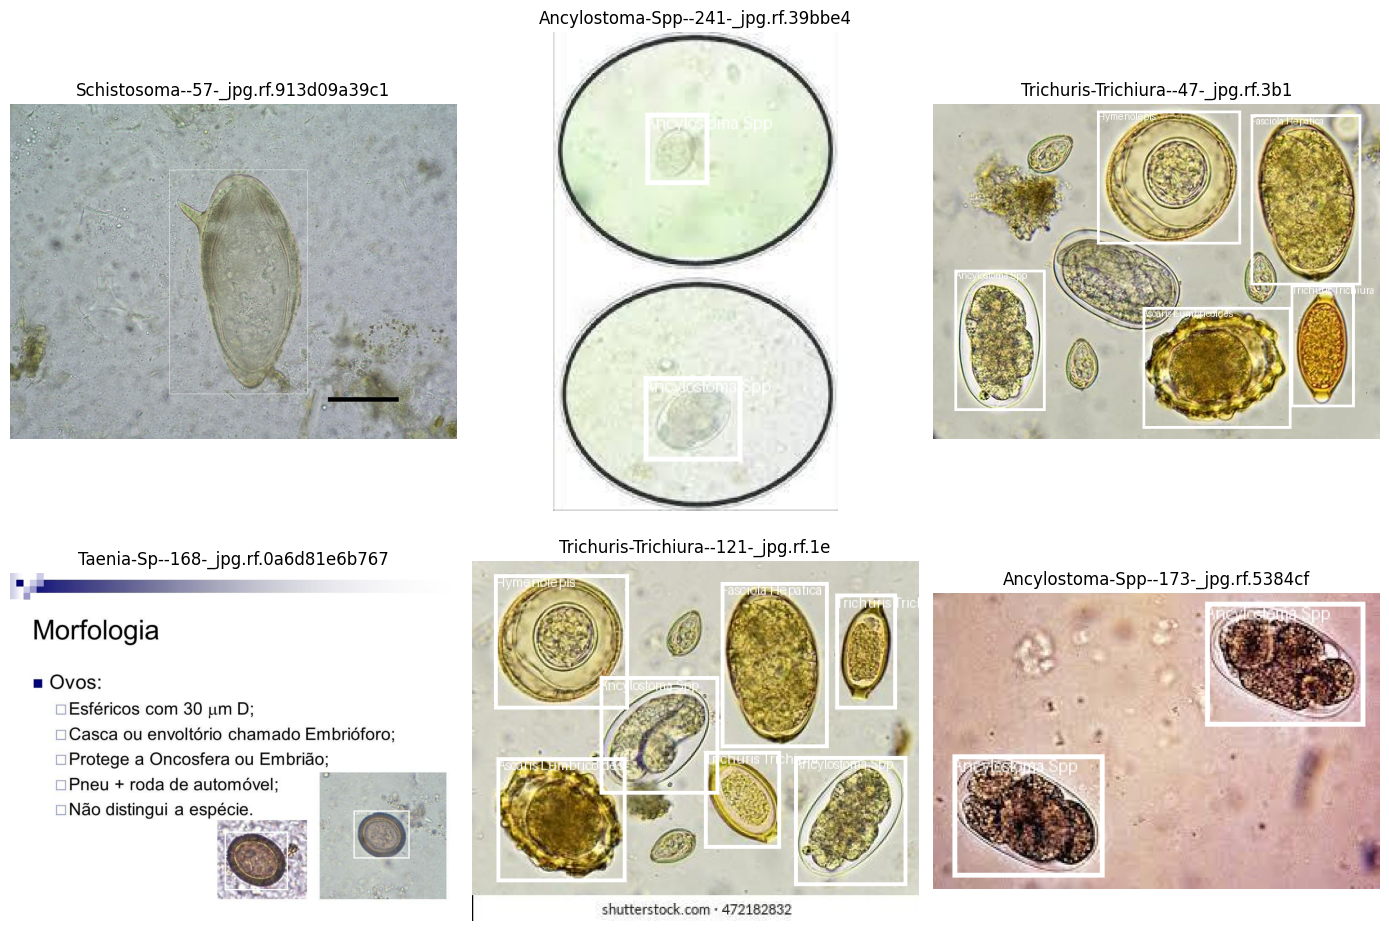

In [45]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import random

def draw_yolo_boxes(image_path, label_path, class_names):
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    image_width, image_height = image.size

    if label_path.exists():
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) == 0:
                    continue

                class_id = int(parts[0])
                x_center = float(parts[1])
                y_center = float(parts[2])
                box_width = float(parts[3])
                box_height = float(parts[4])

                x1 = (x_center - box_width / 2) * image_width
                y1 = (y_center - box_height / 2) * image_height
                x2 = (x_center + box_width / 2) * image_width
                y2 = (y_center + box_height / 2) * image_height

                draw.rectangle([x1, y1, x2, y2], width=3)
                draw.text((x1, y1), class_names[class_id])

    return image

sample_images = random.sample(train_images, 6)

plt.figure(figsize=(14, 10))

for idx, image_path in enumerate(sample_images, start=1):
    label_path = DATA_DIR / "train" / "labels" / f"{image_path.stem}.txt"
    annotated_image = draw_yolo_boxes(image_path, label_path, data_config["names"])

    plt.subplot(2, 3, idx)
    plt.imshow(annotated_image)
    plt.axis("off")
    plt.title(image_path.name[:35])

plt.tight_layout()
plt.show()

### Inspect image dimensions

This cell reads image widths and heights across the dataset.  
Image size information helps guide the input resolution choice for YOLO training.

In [46]:
image_size_records = []

all_image_groups = {
    "train": train_images,
    "valid": val_images,
    "test": test_images
}

for split, images in all_image_groups.items():
    for image_path in images:
        with Image.open(image_path) as image:
            width, height = image.size

        image_size_records.append({
            "split": split,
            "image": image_path.name,
            "width": width,
            "height": height
        })

image_sizes_df = pd.DataFrame(image_size_records)

image_sizes_df.groupby("split")[["width", "height"]].describe()

width                                                              \
        count        mean         std    min    25%    50%    75%     max   
split                                                                       
test    215.0  613.953488  440.806671  100.0  275.5  500.0  838.5  3233.0   
train  1484.0  627.542453  447.104858   86.0  276.0  507.5  863.5  3720.0   
valid   411.0  592.189781  430.648612  100.0  276.0  480.0  778.5  3760.0   

       height                                                              
        count        mean         std    min    25%    50%    75%     max  
split                                                                      
test    215.0  500.562791  349.750611  100.0  225.0  400.0  720.0  2479.0  
train  1484.0  504.837601  372.873372   67.0  225.0  376.5  683.0  2658.0  
valid   411.0  486.751825  370.145735  100.0  233.0  360.0  600.0  3368.0

### Inspect bounding box sizes

This cell calculates the relative area of each bounding box from the YOLO annotation values.  
Bounding box size distribution helps identify whether small-object detection may be an important challenge for this dataset.

In [48]:
box_area_records = []

for split, labels in split_label_groups.items():
    for label_path in labels:
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) == 0:
                    continue

                class_id = int(parts[0])
                width = float(parts[3])
                height = float(parts[4])
                box_area = width * height

                box_area_records.append({
                    "split": split,
                    "class_id": class_id,
                    "class_name": data_config["names"][class_id],
                    "box_area": box_area
                })

box_area_df = pd.DataFrame(box_area_records)

box_area_df.groupby("split")["box_area"].describe()

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,460.0,0.112503,0.142786,0.002432,0.023908,0.059493,0.135503,0.774388
train,3667.0,0.104723,0.149398,0.000664,0.020059,0.052661,0.114419,0.992366
valid,963.0,0.107945,0.154640,0.000440,0.020457,0.044089,0.114333,0.986706


### Plot bounding box size distribution

This cell visualizes the relative area of parasite bounding boxes across the dataset.  
The distribution helps show whether most annotations are small, medium, or large relative to the full image.

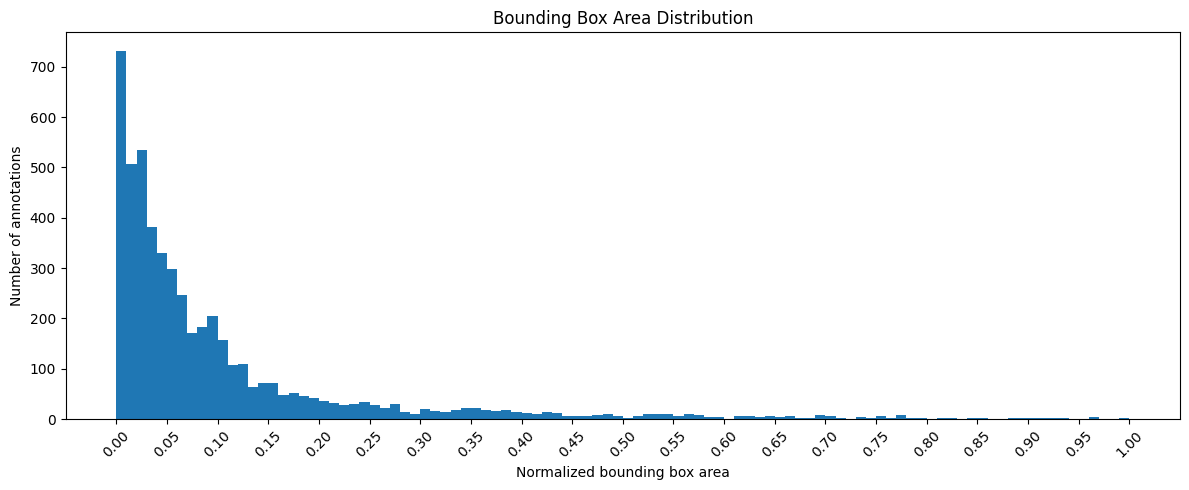

In [66]:
import numpy as np

plt.figure(figsize=(12, 5))

bins = np.arange(0, 1.01, 0.01)
tick_positions = np.arange(0, 1.05, 0.05)

plt.hist(box_area_df["box_area"], bins=bins)

plt.xlabel("Normalized bounding box area")
plt.ylabel("Number of annotations")
plt.title("Bounding Box Area Distribution")
plt.xticks(tick_positions, rotation=45)

plt.tight_layout()
plt.show()

### Check empty label files

This cell checks whether any annotation files contain no labeled objects.  
Empty label files may represent valid negative images, but they should be identified before training.

In [ ]:
empty_label_files = []

for label_path in label_paths:
    if label_path.read_text().strip() == "":
        empty_label_files.append(label_path)

print("Empty label files:", len(empty_label_files))

for path in empty_label_files[:10]:
    print(path)

### Check duplicate images across splits

This cell checks for duplicate image filenames across train, validation, and test splits.  
Duplicate images across splits can cause data leakage and make evaluation results less reliable.

In [ ]:
image_records = []

for split, images in all_image_groups.items():
    for image_path in images:
        image_records.append({
            "split": split,
            "filename": image_path.name,
            "stem": image_path.stem,
            "path": image_path
        })

image_records_df = pd.DataFrame(image_records)

duplicate_stems = (
    image_records_df
    .groupby("stem")
    .filter(lambda group: group["split"].nunique() > 1)
    .sort_values("stem")
)

print("Duplicate image stems across splits:", duplicate_stems["stem"].nunique())

duplicate_stems.head(20)

### Create dataset audit summary

This cell collects the main dataset audit checks into a compact summary.  
The summary provides a quick reference for dataset size, annotation quality, and split integrity before training.

In [70]:
audit_summary = {
    "train_images": len(train_images),
    "valid_images": len(val_images),
    "test_images": len(test_images),
    "train_labels": len(train_labels),
    "valid_labels": len(val_labels),
    "test_labels": len(test_labels),
    "num_classes": data_config["nc"],
    "total_annotations": len(box_area_df),
    "malformed_label_rows": len(bad_rows),
    "invalid_annotations": len(invalid_annotations),
    "empty_label_files": len(empty_label_files),
    "duplicate_filenames_across_splits": duplicate_stems["stem"].nunique()
}

audit_summary_df = pd.DataFrame([audit_summary])
audit_summary_df

,train_images,valid_images,test_images,train_labels,valid_labels,test_labels,num_classes,total_annotations,malformed_label_rows,invalid_annotations,empty_label_files,duplicate_filenames_across_splits
0,1484,411,215,1484,411,215,8,5090,0,0,0,0
